# Plot histograms of prediction model hidden layer PS and  $\Delta$PS
Generates histograms of two distributions:

1) Hidden layer parallelism score $\text{PS}(\,h_{\text{prediction}_i} \circ h_{\text{entangler}}(\mathbf{X}_i)\,)$ for an ensemble of prediction models (each model realization an observation)
   
2) $\text{PS}(h_{\text{prediction}_i} \circ h_{\text{entangler}}(\mathbf{X}_i))- \text{PS}(h_{\text{entanlger}}(\mathbf{X}_0))$, where each prediction model realization is paired with the entangler model used to generate its input (note this can be many-to-one, as multiple prediction models can be trained on input from the same entangler model).

3) Scatterplots of $\text{PS}(h_{\text{prediction}_i} \circ h_{\text{entangler}}(\mathbf{X}_i))$ vs $\text{PS}( h_{\text{entangler}}(\mathbf{X}_i))$

##### Import statements:

In [1]:
import os
import pathlib
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from matplotlib import colormaps
from analysis_metadata.analysis_metadata import Metadata, increment_dir_name, write_metadata

##### Define inputs, parameters:

In [119]:
# Input file:
input_path = os.path.join('/', 'mnt', 'smb', 'locker', 'issa-locker', 'users', 'Dan', 'code', 'ws', 'results', 'run845', 'tngl_pred.pickle')
input_dir = os.path.split(input_path)[0]

# Plotting parameters:
n_bins = None

# Output parameters:
save_output = True

##### Load previously-saved results:

In [120]:
tngl_evo_pred_results = pickle.load(open(input_path, 'rb'))
geo_df = tngl_evo_pred_results['geo_df'] 

##### Get mean hidden layer parallelism score $\text{PS}(\, h_{\text{prediction}_i} \circ h_{\text{entangler}} (\mathbf{X}_i) \,)$ for each prediction model realization $i$:

In [121]:
geo_df_pred = geo_df[geo_df.mdl_type=='prediction']
geo_df_pred_hidden = geo_df_pred[geo_df_pred.layer=='hidden'] # Hidden layer only

# Extract only final training epoch for each entangler model:
max_epoch_pred = geo_df_pred_hidden[['pred_mdl_id', 'epoch']].groupby('pred_mdl_id').apply(lambda x : np.max(x.epoch)).reset_index(name='epoch')
geo_df_pred_hidden = pd.merge(geo_df_pred_hidden, max_epoch_pred, on=['pred_mdl_id', 'epoch'])

# Average across dichotomies, training partitions within each model instance:
par_df_pred_hidden = geo_df_pred_hidden[['tngl_mdl_id', 'pred_mdl_id', 'parallelism']].groupby(['tngl_mdl_id', 'pred_mdl_id']).mean().reset_index()
par_df_pred_hidden = par_df_pred_hidden.rename(columns={'parallelism':'parallelism_pred_hidden'})

##### Get mean input parallelism score $\text{PS}(h_{\text{entangler}}(\mathbf{X}_i))$ for each prediction model:

In [122]:
geo_df_pred_inpt = geo_df_pred[geo_df_pred.layer=='inpt'] # Input layer only
geo_df_pred_inpt = geo_df_pred_inpt[geo_df_pred_inpt.epoch==0] # First epoch only (shouldn't matter though)
par_df_inpt = geo_df_pred_inpt[['pred_mdl_id', 'parallelism']].groupby('pred_mdl_id').mean().mean().values[0]

##### Plot histogram of prediction model parallelism scores $\text{PS}(\, h_{\text{prediction}_i} \circ h_{\text{entangler}} (\mathbf{X}_i) \,)$, with mean input paralleism $\mathbb{E}[\, \text{PS}(\,h_{\text{entangler}}(\mathbf{X}_i))\,]$ for reference

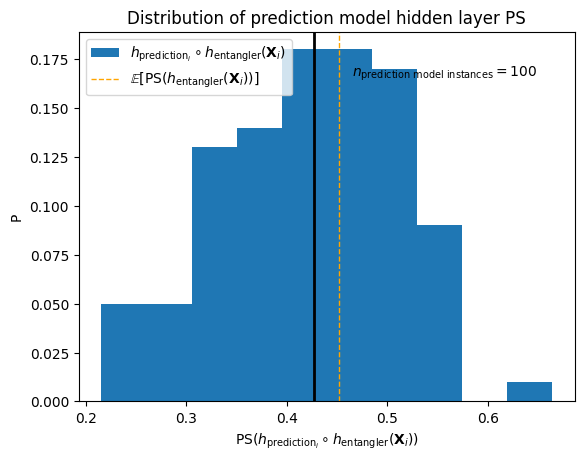

In [123]:
ps_dist_fig = plt.figure()
#leg_str = 'pred. mdl. hidden'
leg_str = r'$h_{\text{prediction}_i} \circ h_{\text{entangler}}(\mathbf{X}_i)$'
plt.hist(par_df_pred_hidden.parallelism_pred_hidden, weights=1/par_df_pred_hidden.shape[0]*np.ones(par_df_pred_hidden.shape[0]), label=leg_str)

plt.ylabel('P')
xlabel_str = r'$\text{PS}( h_{\text{prediction}_i}\circ h_{\text{entangler}}(\mathbf{X}_{i}))$'
plt.xlabel(xlabel_str)

plt.title('Distribution of prediction model hidden layer PS')
n_str = r'$n_{\text{prediction model instances}} = $' + str(par_df_pred_hidden.shape[0])
plt.annotate(n_str, [0.55, 0.8], xycoords='figure fraction')

#inpt_str = 'input'
inpt_str = r'$\mathbb{E}[\text{PS}(h_\text{entangler}(\mathbf{X}_i))]$'
plt.axvline(par_df_inpt, color='orange', linewidth=1, linestyle='--', label=inpt_str)
plt.axvline(np.median(par_df_pred_hidden.parallelism_pred_hidden), color='black', linewidth=2)
plt.legend()

##### Get mean parallelism score $\mathbb{E}[\,\text{PS}(\,h_{\text{entangler}}(\mathbf{X}_0))\,]$ for each entangler model:

In [124]:
geo_df_tngl = geo_df[geo_df.mdl_type=='autoencoder']
geo_df_tngl_hidden = geo_df_tngl[geo_df_tngl.layer=='hidden'] # Hidden layer only

# Extract only final training epoch for each entangler model:
max_epoch_tngl = geo_df_tngl_hidden[['tngl_mdl_id', 'epoch']].groupby('tngl_mdl_id').apply(lambda x : np.max(x.epoch)).reset_index(name='epoch')
geo_df_tngl_hidden = pd.merge(geo_df_tngl_hidden, max_epoch_tngl, on=['tngl_mdl_id', 'epoch'])

# Average across dichotomies, training partitions within each model instance:
par_df_tngl_hidden = geo_df_tngl_hidden[['tngl_mdl_id', 'parallelism']].groupby('tngl_mdl_id').mean().reset_index()
par_df_tngl_hidden = par_df_tngl_hidden.rename(columns={'parallelism':'parallelism_tngl_hidden'})

##### Merge entangler and prediction model parallelism scores, compute difference:

In [125]:
par_df = pd.merge(par_df_tngl_hidden, par_df_pred_hidden, on=['tngl_mdl_id'])
par_df['delta_par'] = par_df['parallelism_pred_hidden'] - par_df['parallelism_tngl_hidden'] 

##### Plot histogram of $\Delta PS = \text{PS}(h_{\text{prediction}_i} \circ h_{\text{entangler}}(\mathbf{X}_i) ) - \text{PS}(h_{\text{entangler}}(\mathbf{X}_0))$:

Text(0.5, 1.0, 'Distribution of hidden layer $\\Delta \\text{PS}$')

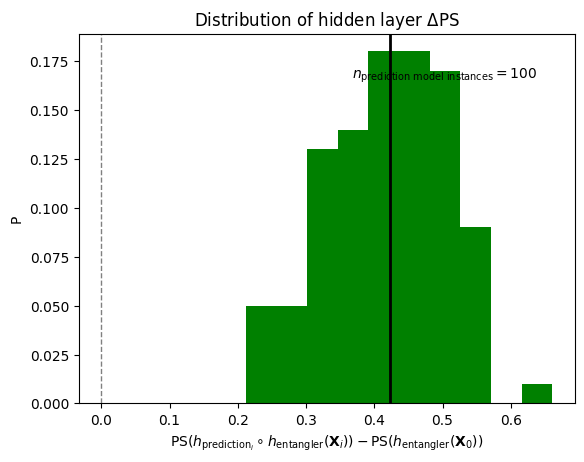

In [126]:
delta_ps_dist_fig = plt.figure()
plt.hist(par_df.delta_par, weights=1/par_df.shape[0]*np.ones(par_df.shape[0]), bins=n_bins, color='green')

plt.ylabel('P')
xlabel_str = r'$\text{PS}(h_{\text{prediction}_i} \circ h_{\text{entangler}}(\mathbf{X}_i)) - \text{PS}(h_{\text{entangler}}(\mathbf{X}_0))$'
plt.xlabel(xlabel_str)

plt.axvline(np.median(par_df.delta_par), color='black', linewidth=2)
plt.axvline(0, color='gray', linewidth=1, linestyle='--')

n_str = r'$n_{\text{prediction model instances}} = $' + str(par_df.shape[0])
plt.annotate(n_str, [0.55, 0.8], xycoords='figure fraction')
plt.title('Distribution of hidden layer ' + r'$\Delta \text{PS}$')

##### Generate scatterplot of $\text{PS}(\, h_{\text{prediction}_i} \circ h_{\text{entangler}}(\mathbf{X}_i) \,)$ vs $\text{PS}\, (h_{\text{entangler}}(\mathbf{X}_i) \,)$ for each simulation:

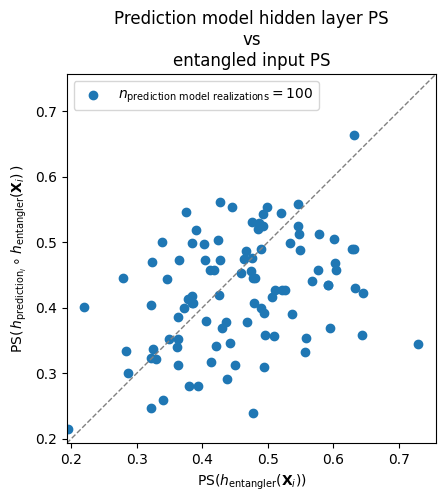

In [138]:
par_df_pred_inpt = geo_df_pred_inpt[['tngl_mdl_id', 'pred_mdl_id', 'parallelism']].groupby(['tngl_mdl_id', 'pred_mdl_id']).mean().reset_index()
par_df_pred_inpt = par_df_pred_inpt.rename(columns={'parallelism':'parallelism_pred_inpt'})

par_df_pred = pd.merge(par_df_pred_hidden, par_df_pred_inpt, on=['tngl_mdl_id', 'pred_mdl_id'])

scatter_fig = plt.figure()
leg_text = r'$n_{{\text{{prediction model realizations}}}} = {}$'.format(par_df_pred.shape[0])
plt.scatter(par_df_pred.parallelism_pred_inpt, par_df_pred.parallelism_pred_hidden, label=leg_text)

xl = plt.xlim()
yl = plt.ylim()
minmin = np.max([xl[0], yl[0]])
maxmax = np.max([xl[1], yl[1]])
plt.ylim([minmin, maxmax])
plt.xlim([minmin, maxmax])
plt.gca().set_aspect('equal')

plt.axline([0,0], slope=1, color='gray', linewidth=1, linestyle='--')

xlabel_str = r'$\text{PS}(h_{\text{entangler}}(\mathbf{X}_i))$'
plt.xlabel(xlabel_str)
ylabel_str = r'$\text{PS}(\, h_{\text{prediction}_i} \circ h_{\text{entangler}}(\mathbf{X}_i) \,)$'
plt.ylabel(ylabel_str)

title = '\n'.join(['Prediction model hidden layer PS', 'vs', 'entangled input PS'])
plt.title(title)

plt.legend()
plt.show()

##### Save output:

In [135]:
if save_output:

    # Create output directory:
    input_dir = os.path.split(input_path)[0]
    base_dir_name = 'ps_hists'
    curr_output_directory = increment_dir_name(input_dir, base_dir_name)
    if not os.path.exists(curr_output_directory):
        pathlib.Path(curr_output_directory).mkdir(parents=True,exist_ok=True)

    # Save figures:
    plt.figure(ps_dist_fig)
    file_basename = 'hist_ps'
    ps_png_path = os.path.join(curr_output_directory, file_basename+'.png')
    plt.savefig(ps_png_path)
    ps_svg_path =  os.path.join(curr_output_directory, file_basename+'.svg')
    plt.savefig(ps_svg_path)

    plt.figure(delta_ps_dist_fig)
    file_basename = 'hist_delta_ps'
    delta_ps_png_path = os.path.join(curr_output_directory, file_basename+'.png')
    plt.savefig(delta_ps_png_path)
    delta_ps_svg_path =  os.path.join(curr_output_directory, file_basename+'.svg')
    plt.savefig(delta_ps_svg_path)

    plt.figure(scatter_fig)
    file_basename = 'scatter_ps_hidden_vs_ps_inpt'
    scatter_fig_png_path = os.path.join(curr_output_directory, file_basename+'.png')
    plt.savefig(scatter_fig_png_path)
    scatter_fig_svg_path =  os.path.join(curr_output_directory, file_basename+'.svg')
    plt.savefig(scatter_fig_svg_path)

    
    # Define metadata:
    M = Metadata()
    M.add_input(input_path)
    M.add_output(ps_png_path)
    M.add_output(ps_svg_path)
    M.add_output(delta_ps_png_path)
    M.add_output(delta_ps_svg_path)
    M.add_output(scatter_fig_png_path)
    M.add_output(scatter_fig_svg_path)
    metadata_path = os.path.join(curr_output_directory, 'ps_hists.json')
    write_metadata(M, metadata_path)

Computing checksum for /mnt/smb/locker/issa-locker/users/Dan/code/ws/results/run845/tngl_pred.pickle...
Computing checksum for /mnt/smb/locker/issa-locker/users/Dan/code/ws/results/run845/ps_hists004/hist_ps.png...
Computing checksum for /mnt/smb/locker/issa-locker/users/Dan/code/ws/results/run845/ps_hists004/hist_ps.svg...
Computing checksum for /mnt/smb/locker/issa-locker/users/Dan/code/ws/results/run845/ps_hists004/hist_delta_ps.png...
Computing checksum for /mnt/smb/locker/issa-locker/users/Dan/code/ws/results/run845/ps_hists004/hist_delta_ps.svg...
Computing checksum for /mnt/smb/locker/issa-locker/users/Dan/code/ws/results/run845/ps_hists004/scatter_ps_hidden_vs_ps_inpt.png...
Computing checksum for /mnt/smb/locker/issa-locker/users/Dan/code/ws/results/run845/ps_hists004/scatter_ps_hidden_vs_ps_inpt.svg...
